# Session 1: CHIPS-Only DBNet Pre-Training

**Goal:** Produce a strong synthetic-word detector that will serve as the starting point for real-page fine-tuning in Part 1.

**Strategy:**
- Train `db_resnet50(pretrained=True)` on 8000 CHIPS synthetic pages
- Validate on 2000 CHIPS synthetic pages
- Save best checkpoint based on validation loss

**What is NOT in this session:**
- ❌ No manual annotations or real pages
- ❌ No self-training or pseudo-labels
- ❌ No threshold 0.1 anywhere
- ❌ No TrOCR, LoRA, or recognition code

**Expected output:** `dbnet_best.pt` with val_loss ≈ 0.03

**Time:** ~8-10 hours on T4 GPU

**Required Kaggle input:**
- `chips-hindi-bigger` → CHIPS synthetic dataset (`chips_hindi/train/`, `chips_hindi/val/`)

In [1]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 0: Install Dependencies
# ══════════════════════════════════════════════════════════════════════════════
!pip install -q "python-doctr[torch]>=1.0" "albumentations==1.3.1" \
    "pillow>=9.0" "opencv-python-headless>=4.8" \
    "matplotlib>=3.7" "numpy>=1.24"

import importlib
for _p in ["doctr", "cv2", "PIL", "numpy"]:
    _m = importlib.import_module(_p)
    print(f"  {_p}: {getattr(_m, '__version__', 'ok')}")
print("All packages ready.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.4/68.4 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 25.0 MB/s eta 0:00:0000:01
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.7/125.7 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.9/288.9 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 82.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 98.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 99.5 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 2.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but 

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 1: Configuration
# ══════════════════════════════════════════════════════════════════════════════
import os, json, time, shutil
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader
os.environ["USE_TORCH"] = "1"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    p = torch.cuda.get_device_properties(0)
    print(f"GPU: {p.name}  VRAM: {p.total_memory/1e9:.1f}GB")

# ── Paths ─────────────────────────────────────────────────────────────────────
# IMPORTANT: Adjust CHIPS_DIR to match YOUR Kaggle dataset mount path
CHIPS_DIR   = Path("/kaggle/input/datasets/nehamalik10/chips-hindi-bigger/chips_hindi")
OUTPUT_DIR  = Path("/kaggle/working/phase4")
DBNET_DIR   = OUTPUT_DIR / "dbnet_ckpt"
CHIPS_TRAIN = OUTPUT_DIR / "chips_train"
CHIPS_VAL   = OUTPUT_DIR / "chips_val"
for d in [OUTPUT_DIR, DBNET_DIR, CHIPS_TRAIN, CHIPS_VAL]:
    d.mkdir(parents=True, exist_ok=True)

# ── Training Hyperparameters ──────────────────────────────────────────────────
DET_IMG_SIZE = 1024
DET_BS       = 4
DET_LR       = 5e-4       # Good for training on synthetic data
DET_WD       = 5e-4
DET_EPOCHS   = 10         # With early stopping
DET_PATIENCE = 4          # Stop if no improvement for 4 epochs
GRAD_CLIP    = 5.0
BEST_CKPT    = DBNET_DIR / "dbnet_best.pt"

print(f"Config: epochs={DET_EPOCHS}, BS={DET_BS}, LR={DET_LR}, img={DET_IMG_SIZE}px")
print("Config ready.")

Device: cuda
GPU: Tesla T4  VRAM: 15.6GB
Config: epochs=10, BS=4, LR=0.0005, img=1024px
Config ready.


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 2: Convert CHIPS COCO → doctr Format + Validate Images
# ══════════════════════════════════════════════════════════════════════════════
from PIL import Image as PILImage

def chips_to_doctr(split_name, out_dir):
    """Convert CHIPS COCO annotations → doctr DetectionDataset format.
    Labels use ABSOLUTE pixel coordinates (doctr normalizes internally)."""
    
    # Find annotations.json
    coco_path = CHIPS_DIR / split_name / "annotations.json"
    if not coco_path.exists():
        print(f"  NOT FOUND: {coco_path}")
        return 0
    
    with open(coco_path, encoding="utf-8") as f:
        coco = json.load(f)
    
    # Find image directory
    img_dir = CHIPS_DIR / split_name / "images"
    if not img_dir.exists() or not any(img_dir.iterdir()):
        img_dir = CHIPS_DIR / split_name  # images directly in split folder
    
    (out_dir / "images").mkdir(parents=True, exist_ok=True)
    
    # Build annotation map
    ann_map = {}
    for a in coco.get("annotations", []):
        ann_map.setdefault(a["image_id"], []).append(a)
    
    labels = {}
    copied = 0
    for img_info in coco.get("images", []):
        fname = img_info["file_name"]
        src = img_dir / fname
        if not src.exists():
            continue
        dst = out_dir / "images" / fname
        if not dst.exists():
            shutil.copy2(src, dst)
        
        W = img_info.get("width", 10000)
        H = img_info.get("height", 10000)
        polys = []
        for a in ann_map.get(img_info["id"], []):
            x, y, w, h = a["bbox"]
            x1, y1 = max(0, int(x)), max(0, int(y))
            x2, y2 = min(W, int(x + w)), min(H, int(y + h))
            if x2 > x1 and y2 > y1:
                polys.append([[x1, y1], [x2, y1], [x2, y2], [x1, y2]])
        if polys:
            labels[fname] = {"polygons": polys}
        copied += 1
    
    with open(out_dir / "labels.json", "w") as f:
        json.dump(labels, f)
    n_boxes = sum(len(v["polygons"]) for v in labels.values())
    print(f"  {split_name}: {copied} images, {n_boxes:,} boxes")
    return copied

print("Converting CHIPS annotations to doctr format...")
for split, out in [("train", CHIPS_TRAIN), ("val", CHIPS_VAL)]:
    chips_to_doctr(split, out)
print("CHIPS conversion done.")

# ── Validate images (remove corrupted ones) ─────────────────────────────────
print("\nValidating images...")
for split_dir in [CHIPS_TRAIN, CHIPS_VAL]:
    labels = json.load(open(split_dir / "labels.json"))
    removed = 0
    for fname in list(labels.keys()):
        path = split_dir / "images" / fname
        try:
            PILImage.open(path).verify()
        except Exception:
            os.remove(path)
            del labels[fname]
            removed += 1
    with open(split_dir / "labels.json", "w") as f:
        json.dump(labels, f)
    print(f"  {split_dir.name}: removed {removed} corrupted images")
print("Image validation complete.")

Converting CHIPS annotations to doctr format...
  train: 8000 images, 418,902 boxes
  val: 2000 images, 104,916 boxes
CHIPS conversion done.

Validating images...
  chips_train: removed 0 corrupted images
  chips_val: removed 0 corrupted images
Image validation complete.


In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 3: Build Datasets, Model & Training Loop
# ══════════════════════════════════════════════════════════════════════════════
# Expected time: ~8-10 hours on T4

from doctr.models import db_resnet50
from doctr.datasets import DetectionDataset
from doctr.transforms import Resize

# ── Datasets ──────────────────────────────────────────────────────────────────
resize_tf = Resize((DET_IMG_SIZE, DET_IMG_SIZE))

train_ds = DetectionDataset(
    img_folder=str(CHIPS_TRAIN / "images"),
    label_path=str(CHIPS_TRAIN / "labels.json"),
    sample_transforms=resize_tf,
)
val_ds = DetectionDataset(
    img_folder=str(CHIPS_VAL / "images"),
    label_path=str(CHIPS_VAL / "labels.json"),
    sample_transforms=resize_tf,
)

train_dl = DataLoader(train_ds, batch_size=DET_BS, shuffle=True,
                      collate_fn=DetectionDataset.collate_fn,
                      num_workers=2, pin_memory=True)
val_dl = DataLoader(val_ds, batch_size=DET_BS, shuffle=False,
                    collate_fn=DetectionDataset.collate_fn,
                    num_workers=2, pin_memory=True)

print(f"CHIPS train: {len(train_ds)} pages")
print(f"CHIPS val:   {len(val_ds)} pages")

# ── Model ──────────────────────────────────────────────────────────────────────
det_model = db_resnet50(pretrained=True).to(DEVICE)
# NOTE: Do NOT set postprocessor thresholds here — they are irrelevant during
# training (only the DBNet loss matters). We set them at inference time only.

# ── Optimizer + Scheduler ─────────────────────────────────────────────────────
optimizer = optim.AdamW(det_model.parameters(), lr=DET_LR, weight_decay=DET_WD)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=3, min_lr=1e-6
)

# ── Training Loop ─────────────────────────────────────────────────────────────
best_val_loss = float("inf")
no_improve = 0
train_losses = []
val_losses = []

print(f"\nTraining DBNet on CHIPS: {DET_EPOCHS} epochs, LR={DET_LR}, BS={DET_BS}")
print("=" * 70)

for epoch in range(1, DET_EPOCHS + 1):
    t0 = time.time()
    
    # ── Train ──
    det_model.train()
    ep_loss = 0.0
    n_batches = 0
    for imgs, tgts in train_dl:
        imgs = imgs.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        out = det_model(imgs, target=tgts, return_model_output=False, return_preds=False)
        loss = out["loss"]
        loss.backward()
        nn.utils.clip_grad_norm_(det_model.parameters(), GRAD_CLIP)
        optimizer.step()
        ep_loss += loss.item()
        n_batches += 1
    avg_train = ep_loss / max(n_batches, 1)
    train_losses.append(avg_train)
    
    # ── Validate ──
    det_model.eval()
    vl_loss = 0.0
    n_val = 0
    with torch.no_grad():
        for imgs, tgts in val_dl:
            imgs = imgs.to(DEVICE)
            out = det_model(imgs, target=tgts, return_model_output=False, return_preds=False)
            vl_loss += out["loss"].item()
            n_val += 1
    avg_val = vl_loss / max(n_val, 1)
    val_losses.append(avg_val)
    
    scheduler.step(avg_val)
    elapsed = time.time() - t0
    lr = optimizer.param_groups[0]["lr"]
    
    # ── Early stopping ──
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save(det_model.state_dict(), BEST_CKPT)
        no_improve = 0
        marker = "  ✅ New best → saved"
    else:
        no_improve += 1
        marker = f"  (patience {no_improve}/{DET_PATIENCE})"
    
    print(f"  Epoch {epoch:3d}/{DET_EPOCHS}  "
          f"train={avg_train:.4f}  val={avg_val:.4f}  "
          f"lr={lr:.2e}  t={elapsed:.0f}s{marker}")
    
    if no_improve >= DET_PATIENCE:
        print(f"  Early stopping at epoch {epoch}.")
        break

print(f"\nDBNet CHIPS training complete.")
print(f"Best val_loss: {best_val_loss:.4f}")
print(f"Checkpoint: {BEST_CKPT}")

CHIPS train: 8000 pages
CHIPS val:   2000 pages


  0%|          | 0/102021912 [00:00<?, ?it/s]


Training DBNet on CHIPS: 10 epochs, LR=0.0005, BS=4
  Epoch   1/10  train=0.1390  val=0.0716  lr=5.00e-04  t=2611s  ✅ New best → saved
  Epoch   2/10  train=0.0622  val=0.0526  lr=5.00e-04  t=2607s  ✅ New best → saved
  Epoch   3/10  train=0.0480  val=0.0429  lr=5.00e-04  t=2610s  ✅ New best → saved
  Epoch   4/10  train=0.0411  val=0.0378  lr=5.00e-04  t=2609s  ✅ New best → saved
  Epoch   5/10  train=0.0370  val=0.0412  lr=5.00e-04  t=2617s  (patience 1/4)
  Epoch   6/10  train=0.0342  val=0.0317  lr=5.00e-04  t=2615s  ✅ New best → saved
  Epoch   7/10  train=0.0319  val=0.0321  lr=5.00e-04  t=2611s  (patience 1/4)
  Epoch   8/10  train=0.0304  val=0.0493  lr=5.00e-04  t=2605s  (patience 2/4)
  Epoch   9/10  train=0.0292  val=1.9132  lr=5.00e-04  t=2611s  (patience 3/4)
  Epoch  10/10  train=0.0279  val=0.0285  lr=5.00e-04  t=2610s  ✅ New best → saved

DBNet CHIPS training complete.
Best val_loss: 0.0285
Checkpoint: /kaggle/working/phase4/dbnet_ckpt/dbnet_best.pt


BOX COUNT COMPARISON (20 val pages)
  Ground Truth (CHIPS):       Mean=53.4  Min=30  Max=80
  Strategy 1 (bin=0.3):       Mean=239.8  Min=120  Max=390
  Strategy 2 (bin=0.5):       Mean=107.7  Min=39  Max=177
  Strategy 3 (0.3+merge):     Mean=35.8  Min=16  Max=54

Target: The strategy closest to GT mean is best.


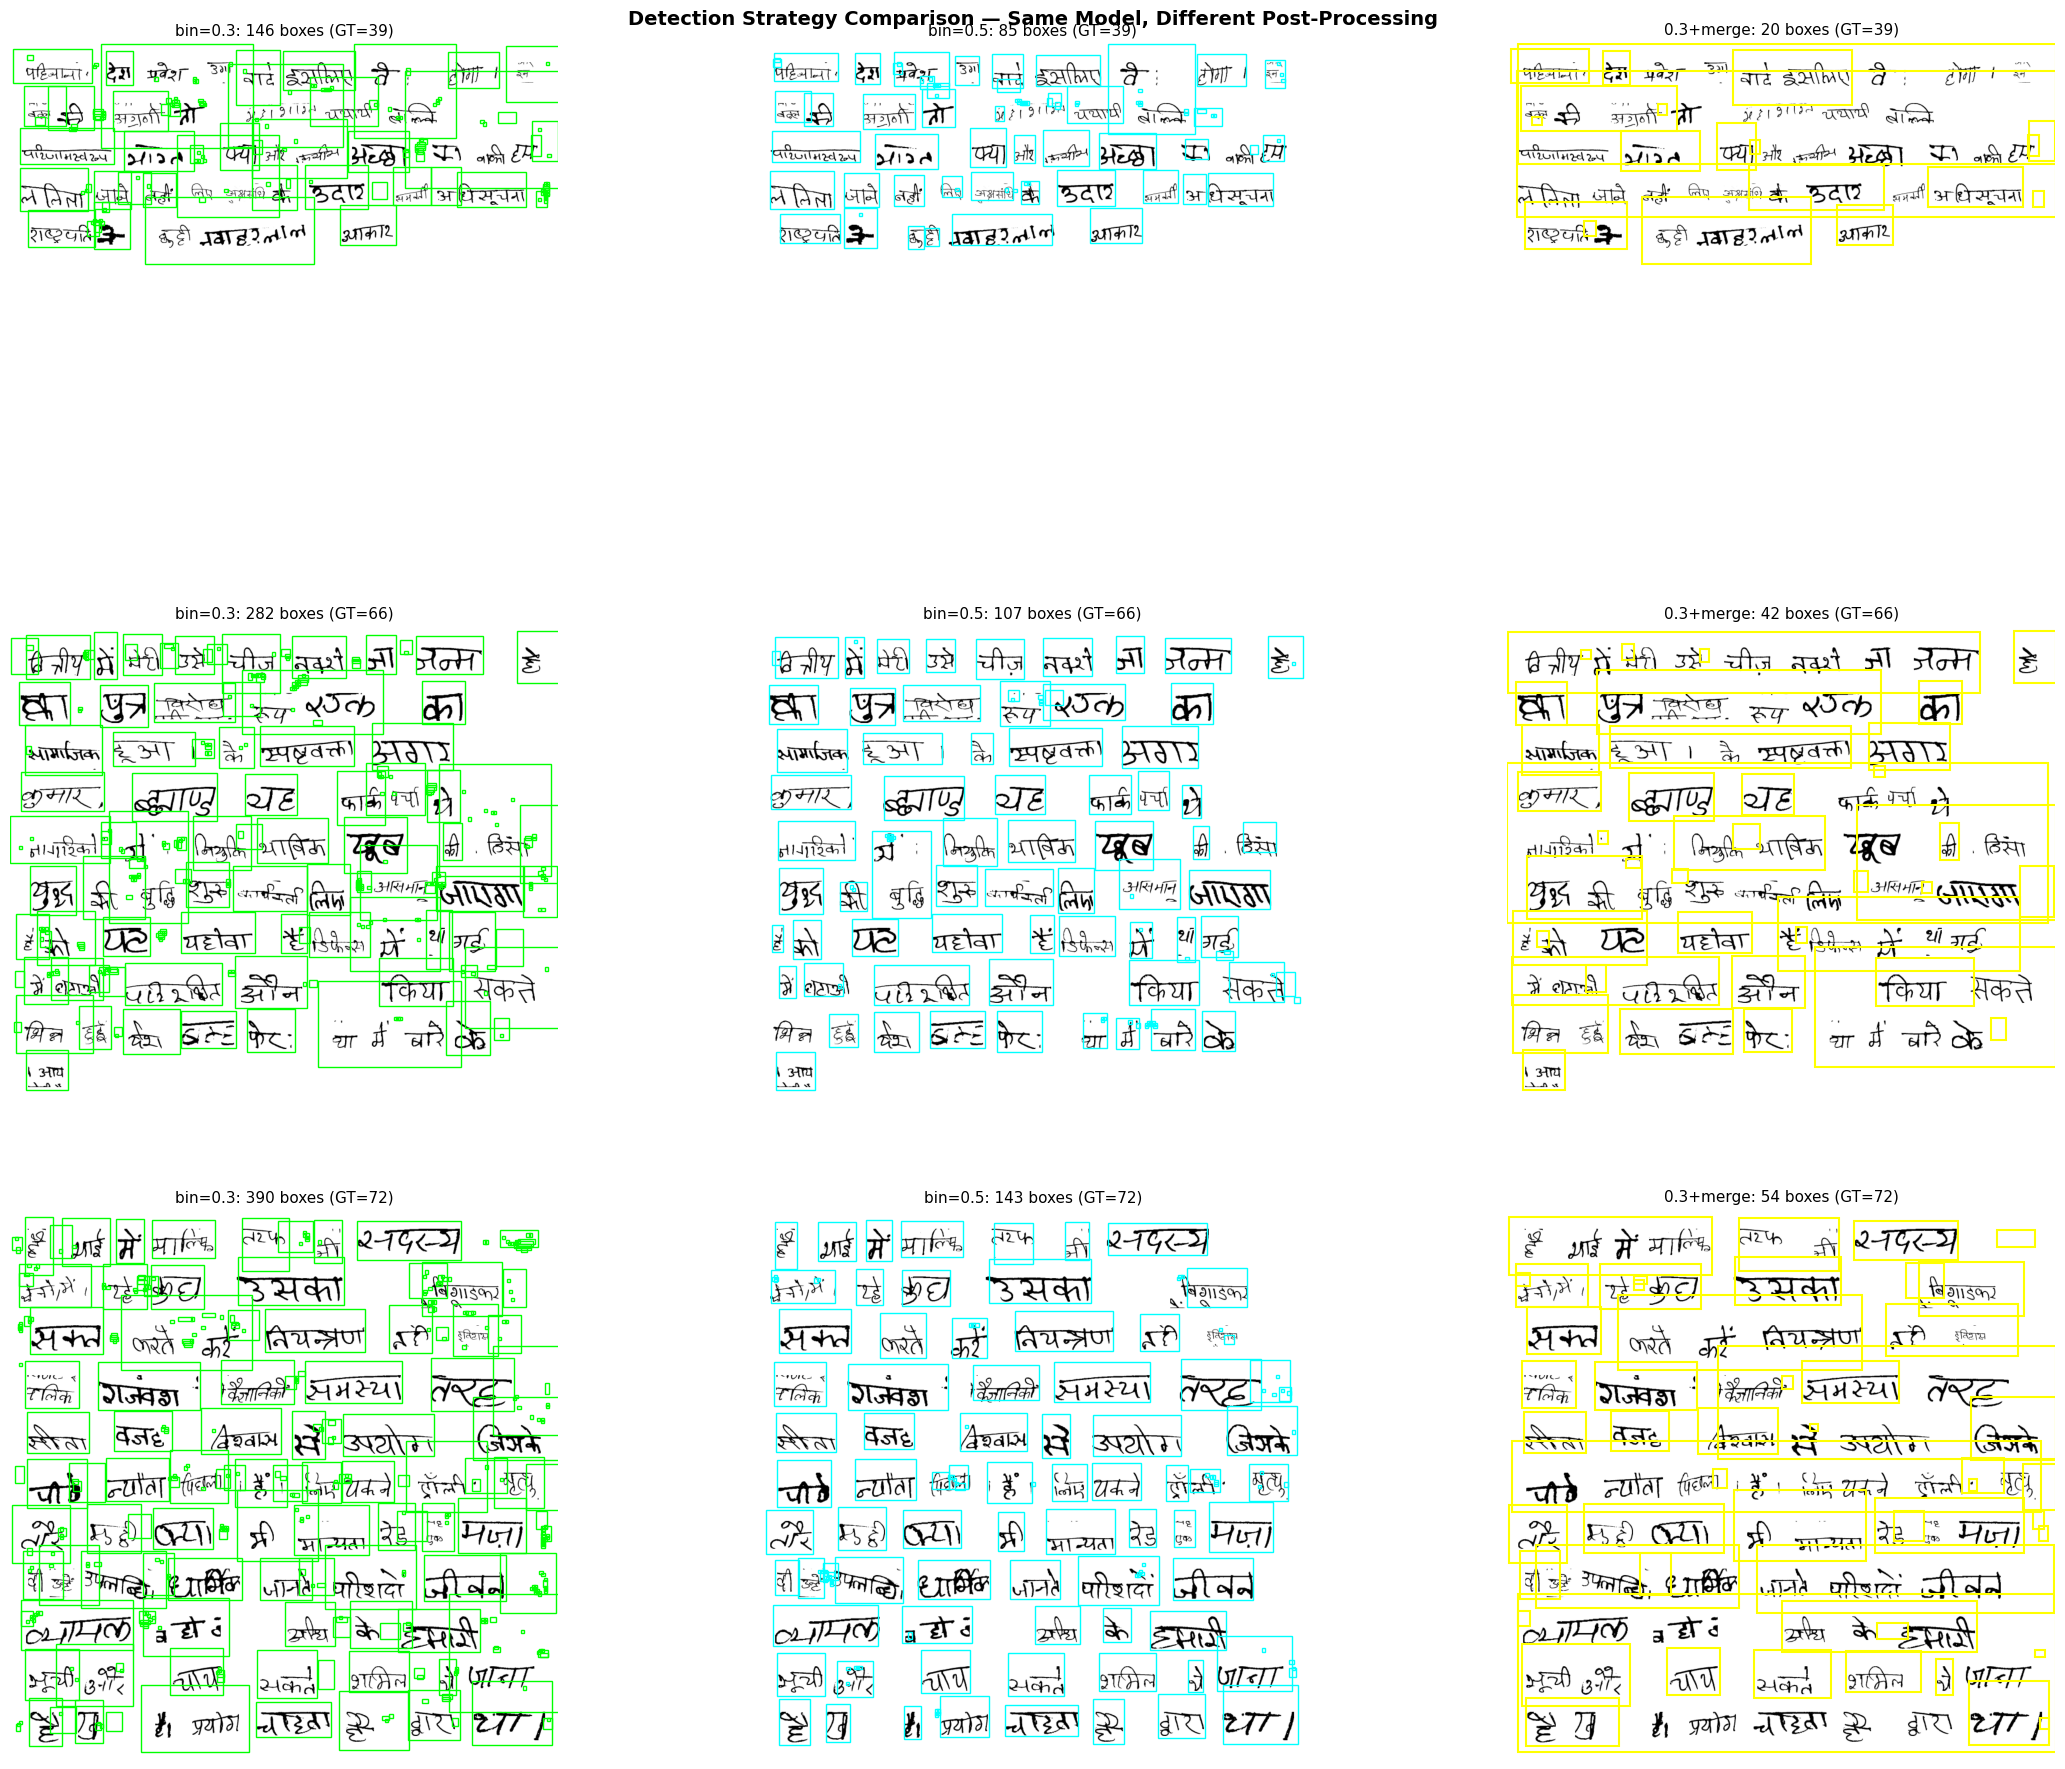


Saved: strategy_comparison.png


In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# DIAGNOSTIC CELL: Test Different Post-Processing Strategies
# ══════════════════════════════════════════════════════════════════════════════
# Run this AFTER Cell 3 (model training) to find the best inference settings.
# This does NOT retrain the model — it only changes how we read the output.
# ══════════════════════════════════════════════════════════════════════════════

import cv2
import numpy as np
import matplotlib.pyplot as plt
from doctr.models import db_resnet50
from doctr.models.detection.predictor import DetectionPredictor
from doctr.models.preprocessor import PreProcessor

# ── Load best checkpoint ─────────────────────────────────────────────────────
det_eval = db_resnet50(pretrained=False)
det_eval.load_state_dict(torch.load(BEST_CKPT, map_location="cpu", weights_only=False))
det_eval = det_eval.to(DEVICE).eval()

# ── Strategy 1: Your current settings (bin=0.3, box=0.3) ────────────────────
det_eval.postprocessor.bin_thresh = 0.3
det_eval.postprocessor.box_thresh = 0.3

pre = PreProcessor(
    (DET_IMG_SIZE, DET_IMG_SIZE), batch_size=1,
    mean=(0.798, 0.785, 0.772), std=(0.264, 0.2749, 0.287),
    preserve_aspect_ratio=True
)
predictor_03 = DetectionPredictor(pre_processor=pre, model=det_eval)

# ── Strategy 2: Higher bin_thresh (bin=0.5, box=0.3) ────────────────────────
# NOTE: This doesn't change any saved constant. It's just for this comparison.
det_eval2 = db_resnet50(pretrained=False)
det_eval2.load_state_dict(torch.load(BEST_CKPT, map_location="cpu", weights_only=False))
det_eval2 = det_eval2.to(DEVICE).eval()
det_eval2.postprocessor.bin_thresh = 0.5
det_eval2.postprocessor.box_thresh = 0.3
predictor_05 = DetectionPredictor(pre_processor=pre, model=det_eval2)

# ── Strategy 3: bin=0.3 + proximity merging ──────────────────────────────────
def merge_nearby_boxes(boxes_raw, img_w, img_h, x_gap=15, y_overlap=0.5):
    """Merge boxes that are horizontally close and vertically aligned (same line).
    
    This fixes the fragmentation problem: character-level fragments that
    belong to the same word get merged back into word-level boxes.
    
    Args:
        boxes_raw: (N, 5) array with [x1_norm, y1_norm, x2_norm, y2_norm, conf]
        img_w, img_h: image dimensions
        x_gap: max horizontal gap in pixels to merge (typical character spacing)
        y_overlap: min vertical overlap ratio to consider same line
    """
    if len(boxes_raw) == 0:
        return boxes_raw
    
    # Convert to pixel coords
    boxes = []
    for b in boxes_raw:
        x1 = float(b[0]) * img_w
        y1 = float(b[1]) * img_h
        x2 = float(b[2]) * img_w
        y2 = float(b[3]) * img_h
        conf = float(b[4])
        boxes.append([x1, y1, x2, y2, conf])
    
    # Sort by x1 (left to right)
    boxes.sort(key=lambda b: b[0])
    
    merged = True
    while merged:
        merged = False
        new_boxes = []
        used = [False] * len(boxes)
        
        for i in range(len(boxes)):
            if used[i]:
                continue
            
            bx1, by1, bx2, by2, bconf = boxes[i]
            
            for j in range(i + 1, len(boxes)):
                if used[j]:
                    continue
                
                cx1, cy1, cx2, cy2, cconf = boxes[j]
                
                # Check horizontal proximity
                h_gap = cx1 - bx2  # gap between right edge of b and left edge of c
                if h_gap > x_gap:
                    continue  # too far apart horizontally
                if h_gap < -min(bx2 - bx1, cx2 - cx1) * 0.5:
                    continue  # too much overlap (probably different elements)
                
                # Check vertical alignment (same line)
                overlap_y1 = max(by1, cy1)
                overlap_y2 = min(by2, cy2)
                if overlap_y2 <= overlap_y1:
                    continue  # no vertical overlap
                
                overlap_h = overlap_y2 - overlap_y1
                min_h = min(by2 - by1, cy2 - cy1)
                if min_h <= 0 or overlap_h / min_h < y_overlap:
                    continue  # not enough vertical overlap
                
                # Merge!
                bx1 = min(bx1, cx1)
                by1 = min(by1, cy1)
                bx2 = max(bx2, cx2)
                by2 = max(by2, cy2)
                bconf = max(bconf, cconf)
                used[j] = True
                merged = True
            
            new_boxes.append([bx1, by1, bx2, by2, bconf])
            used[i] = True
        
        boxes = new_boxes
    
    # Convert back to normalized coords
    result = np.zeros((len(boxes), 5), dtype=np.float32)
    for i, (x1, y1, x2, y2, conf) in enumerate(boxes):
        result[i] = [x1/img_w, y1/img_h, x2/img_w, y2/img_h, conf]
    
    return result

def filter_tiny_boxes(boxes_raw, img_w, img_h, min_w=15, min_h=10):
    """Remove boxes smaller than word-level (noise fragments)."""
    if len(boxes_raw) == 0:
        return boxes_raw
    
    keep = []
    for b in boxes_raw:
        w = float(b[2] - b[0]) * img_w
        h = float(b[3] - b[1]) * img_h
        if w >= min_w and h >= min_h:
            keep.append(b)
    
    return np.array(keep) if keep else np.zeros((0, 5), dtype=np.float32)


# ── Run comparison on 20 val images ──────────────────────────────────────────
val_img_dir = CHIPS_VAL / "images"
val_images = sorted(val_img_dir.glob("*.*"))[:20]

# Load CHIPS GT for comparison
with open(CHIPS_VAL / "labels.json") as f:
    gt_labels = json.load(f)

counts_03 = []
counts_05 = []
counts_merged = []
counts_gt = []

for img_path in val_images:
    img = cv2.imread(str(img_path))
    if img is None:
        continue
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    
    # GT count
    fname = img_path.name
    gt_n = len(gt_labels.get(fname, {}).get("polygons", []))
    counts_gt.append(gt_n)
    
    # Strategy 1: bin=0.3
    raw = predictor_03([img_rgb])[0]
    if isinstance(raw, dict):
        raw = raw.get('words', np.zeros((0, 5)))
    if not isinstance(raw, np.ndarray) or raw.ndim != 2:
        raw = np.zeros((0, 5))
    counts_03.append(len(raw))
    
    # Strategy 2: bin=0.5
    raw2 = predictor_05([img_rgb])[0]
    if isinstance(raw2, dict):
        raw2 = raw2.get('words', np.zeros((0, 5)))
    if not isinstance(raw2, np.ndarray) or raw2.ndim != 2:
        raw2 = np.zeros((0, 5))
    counts_05.append(len(raw2))
    
    # Strategy 3: bin=0.3 + filter + merge
    filtered = filter_tiny_boxes(raw, w, h, min_w=15, min_h=10)
    merged = merge_nearby_boxes(filtered, w, h, x_gap=15, y_overlap=0.4)
    counts_merged.append(len(merged))

# ── Print comparison ─────────────────────────────────────────────────────────
print("="*70)
print("BOX COUNT COMPARISON (20 val pages)")
print("="*70)
print(f"  Ground Truth (CHIPS):       Mean={np.mean(counts_gt):.1f}  "
      f"Min={min(counts_gt)}  Max={max(counts_gt)}")
print(f"  Strategy 1 (bin=0.3):       Mean={np.mean(counts_03):.1f}  "
      f"Min={min(counts_03)}  Max={max(counts_03)}")
print(f"  Strategy 2 (bin=0.5):       Mean={np.mean(counts_05):.1f}  "
      f"Min={min(counts_05)}  Max={max(counts_05)}")
print(f"  Strategy 3 (0.3+merge):     Mean={np.mean(counts_merged):.1f}  "
      f"Min={min(counts_merged)}  Max={max(counts_merged)}")
print()
print("Target: The strategy closest to GT mean is best.")

# ── Visual comparison on 3 pages ─────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(24, 18))

for row, img_path in enumerate(val_images[:3]):
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    fname = img_path.name
    gt_n = len(gt_labels.get(fname, {}).get("polygons", []))
    
    # Strategy 1
    raw = predictor_03([img_rgb])[0]
    if isinstance(raw, dict):
        raw = raw.get('words', np.zeros((0, 5)))
    if not isinstance(raw, np.ndarray) or raw.ndim != 2:
        raw = np.zeros((0, 5))
    
    axes[row][0].imshow(img_rgb)
    for b in raw:
        x1, y1, x2, y2 = float(b[0])*w, float(b[1])*h, float(b[2])*w, float(b[3])*h
        axes[row][0].add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1,
            linewidth=1, edgecolor='lime', facecolor='none'))
    axes[row][0].set_title(f"bin=0.3: {len(raw)} boxes (GT={gt_n})", fontsize=11)
    axes[row][0].axis('off')
    
    # Strategy 2
    raw2 = predictor_05([img_rgb])[0]
    if isinstance(raw2, dict):
        raw2 = raw2.get('words', np.zeros((0, 5)))
    if not isinstance(raw2, np.ndarray) or raw2.ndim != 2:
        raw2 = np.zeros((0, 5))
    
    axes[row][1].imshow(img_rgb)
    for b in raw2:
        x1, y1, x2, y2 = float(b[0])*w, float(b[1])*h, float(b[2])*w, float(b[3])*h
        axes[row][1].add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1,
            linewidth=1, edgecolor='cyan', facecolor='none'))
    axes[row][1].set_title(f"bin=0.5: {len(raw2)} boxes (GT={gt_n})", fontsize=11)
    axes[row][1].axis('off')
    
    # Strategy 3
    filtered = filter_tiny_boxes(raw, w, h, min_w=15, min_h=10)
    merged_boxes = merge_nearby_boxes(filtered, w, h, x_gap=15, y_overlap=0.4)
    
    axes[row][2].imshow(img_rgb)
    for b in merged_boxes:
        x1, y1, x2, y2 = float(b[0])*w, float(b[1])*h, float(b[2])*w, float(b[3])*h
        axes[row][2].add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1,
            linewidth=1.5, edgecolor='yellow', facecolor='none'))
    axes[row][2].set_title(f"0.3+merge: {len(merged_boxes)} boxes (GT={gt_n})", fontsize=11)
    axes[row][2].axis('off')

plt.suptitle("Detection Strategy Comparison — Same Model, Different Post-Processing",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "strategy_comparison.png", dpi=120, bbox_inches='tight')
plt.show()

print("\nSaved: strategy_comparison.png")


In [15]:
# ══════════════════════════════════════════════════════════════════════════════
# Quick Tune: Try tighter merge gaps to hit ~53 boxes/page
# Run this right after the strategy comparison cell.
# ══════════════════════════════════════════════════════════════════════════════

# Test multiple x_gap values to find the sweet spot
for gap in [5, 8, 10, 12]:
    counts = []
    for img_path in val_images[:20]:
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        
        raw = predictor_03([img_rgb])[0]
        if isinstance(raw, dict):
            raw = raw.get('words', np.zeros((0, 5)))
        if not isinstance(raw, np.ndarray) or raw.ndim != 2:
            raw = np.zeros((0, 5))
        
        filtered = filter_tiny_boxes(raw, w, h, min_w=15, min_h=10)
        merged = merge_nearby_boxes(filtered, w, h, x_gap=gap, y_overlap=0.4)
        counts.append(len(merged))
    
    print(f"  x_gap={gap:2d}px → Mean={np.mean(counts):.1f}  "
          f"Min={min(counts)}  Max={max(counts)}  "
          f"(GT=53.4)")

# Also test bin=0.5 + merge combos
print()
for gap in [8, 10, 12]:
    counts = []
    for img_path in val_images[:20]:
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        
        raw = predictor_05([img_rgb])[0]
        if isinstance(raw, dict):
            raw = raw.get('words', np.zeros((0, 5)))
        if not isinstance(raw, np.ndarray) or raw.ndim != 2:
            raw = np.zeros((0, 5))
        
        filtered = filter_tiny_boxes(raw, w, h, min_w=15, min_h=10)
        merged = merge_nearby_boxes(filtered, w, h, x_gap=gap, y_overlap=0.4)
        counts.append(len(merged))
    
    print(f"  bin=0.5 + x_gap={gap:2d}px → Mean={np.mean(counts):.1f}  "
          f"Min={min(counts)}  Max={max(counts)}  "
          f"(GT=53.4)")

  x_gap= 5px → Mean=42.9  Min=19  Max=70  (GT=53.4)
  x_gap= 8px → Mean=40.2  Min=19  Max=65  (GT=53.4)
  x_gap=10px → Mean=39.5  Min=19  Max=62  (GT=53.4)
  x_gap=12px → Mean=37.4  Min=19  Max=58  (GT=53.4)

  bin=0.5 + x_gap= 8px → Mean=53.4  Min=30  Max=79  (GT=53.4)
  bin=0.5 + x_gap=10px → Mean=52.0  Min=29  Max=79  (GT=53.4)
  bin=0.5 + x_gap=12px → Mean=51.0  Min=29  Max=78  (GT=53.4)


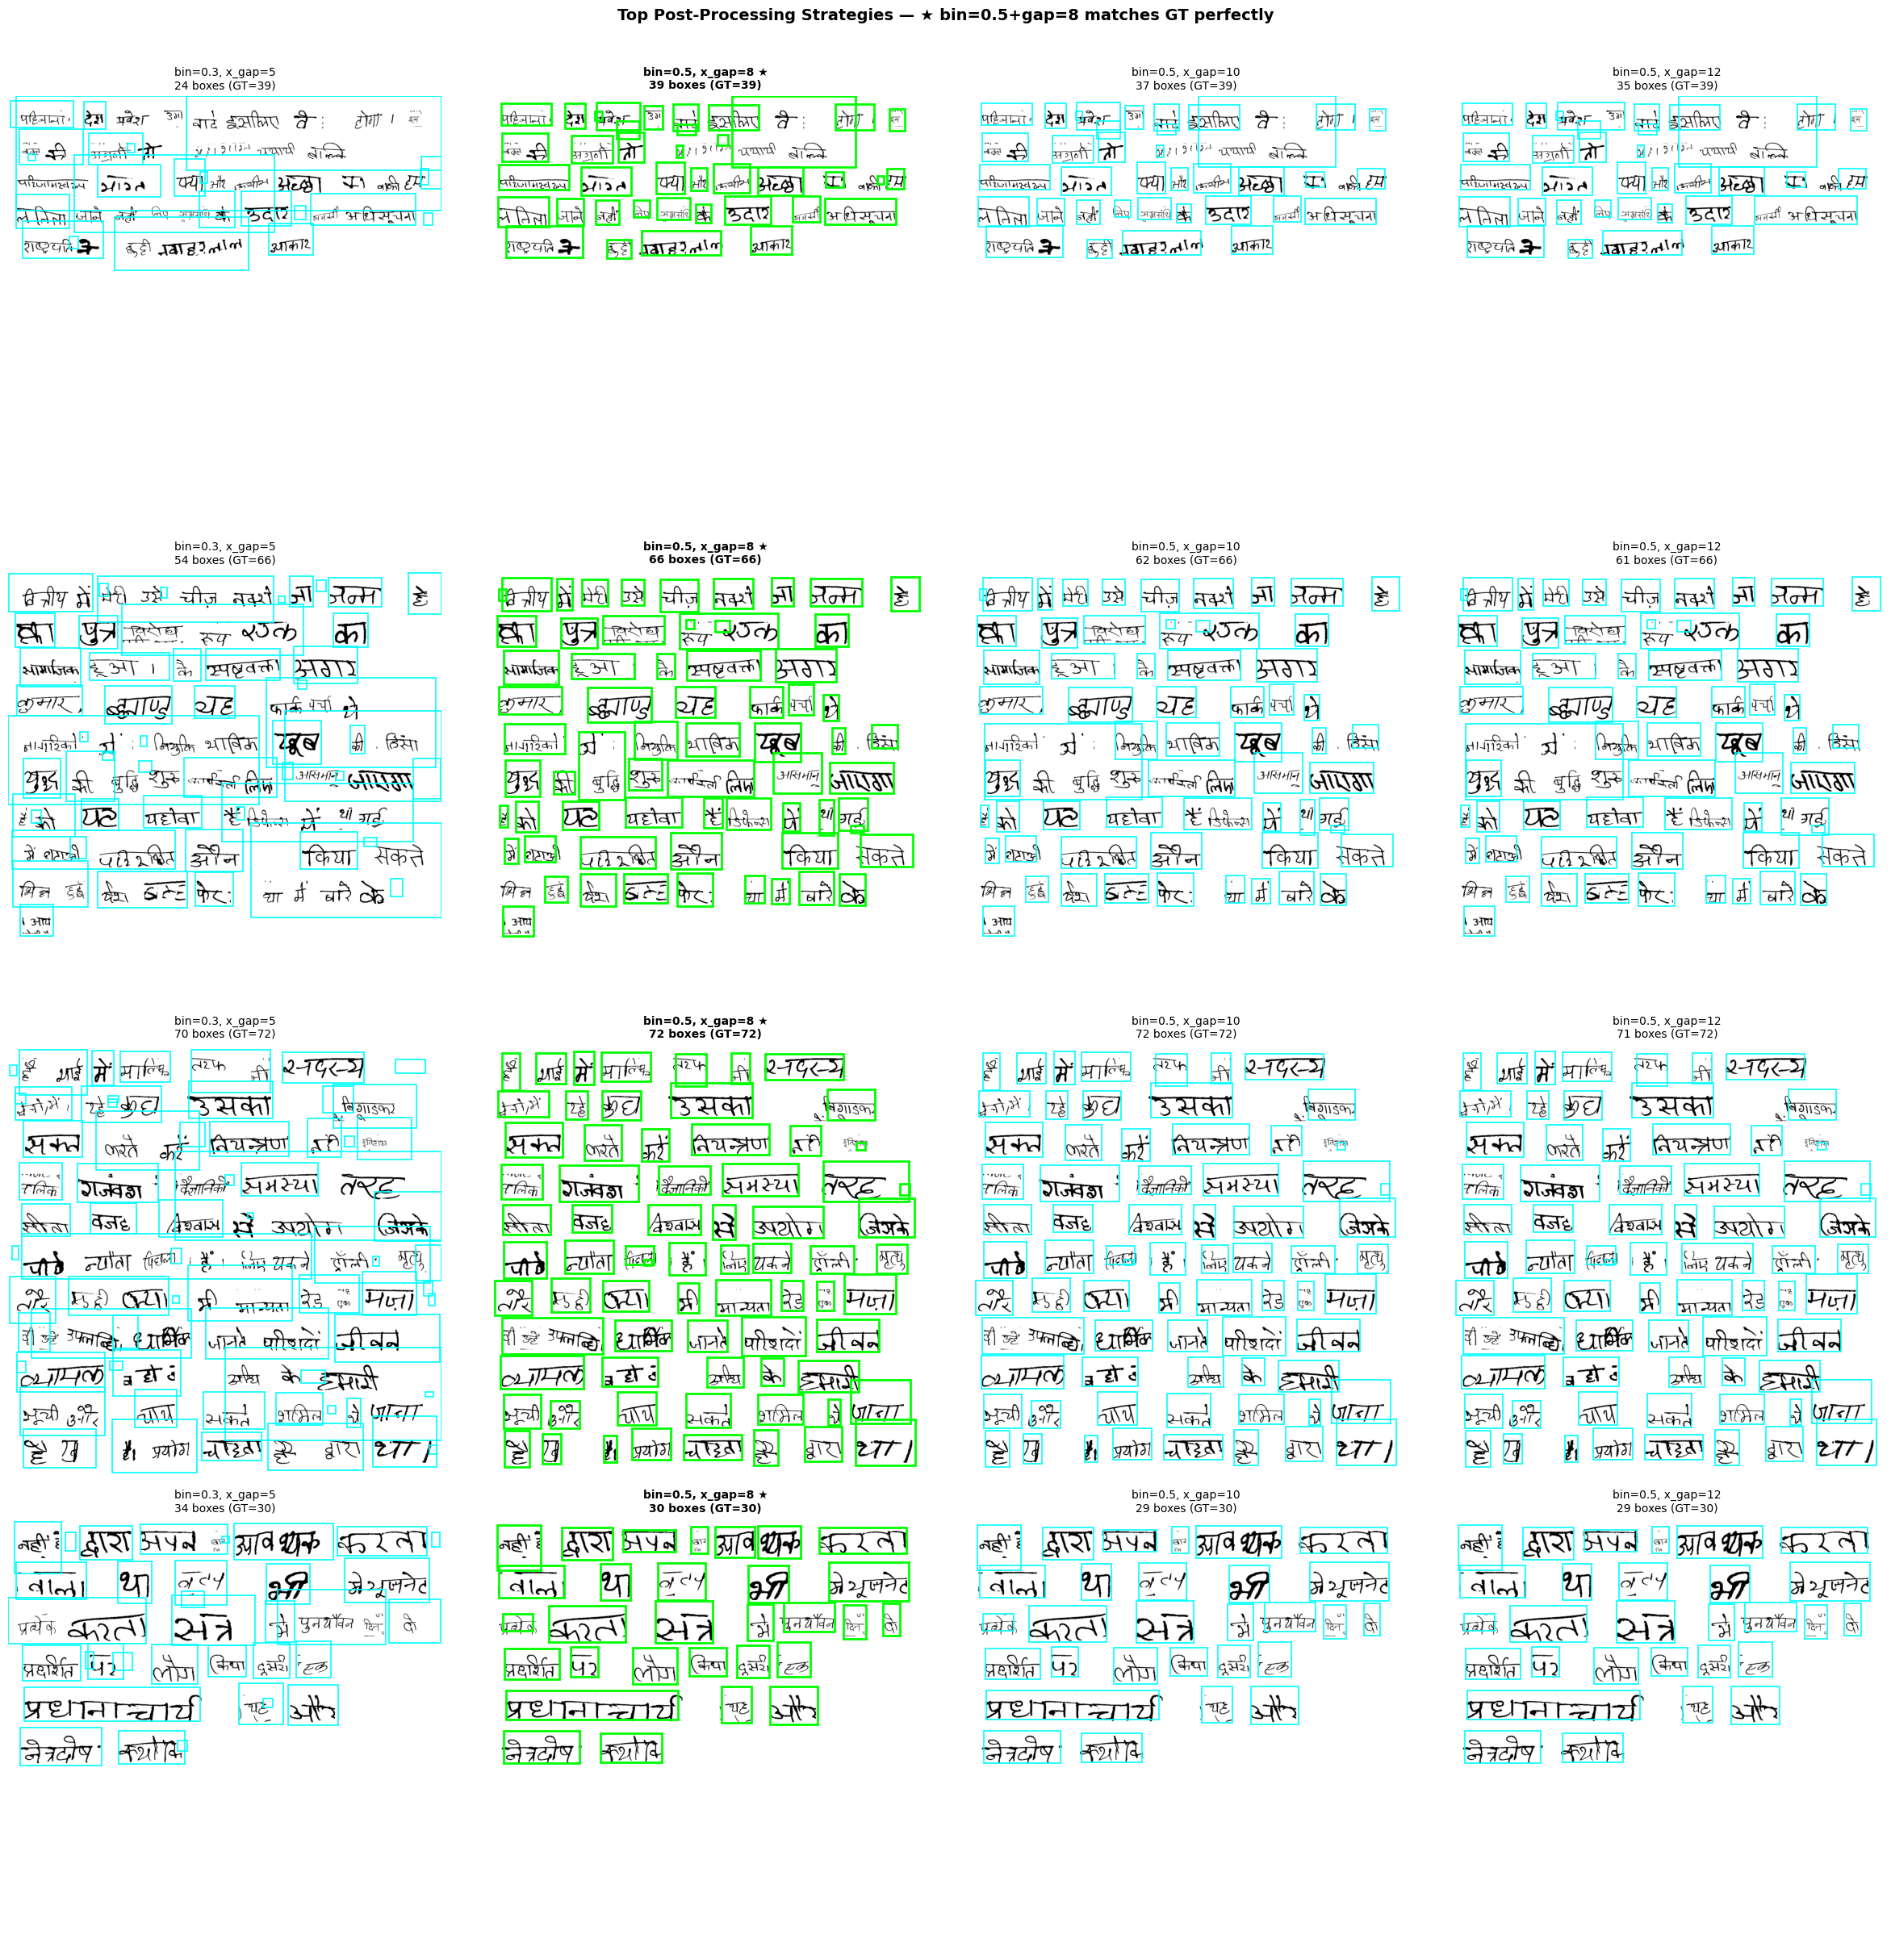

Saved: top_strategies_visual.png


In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# Visual Comparison of Top Strategies
# Run after the tuning cell. Shows side-by-side detection on 4 val pages.
# ══════════════════════════════════════════════════════════════════════════════

top_strategies = [
    ("bin=0.3, x_gap=5",  0.3, 5),
    ("bin=0.5, x_gap=8",  0.5, 8),   # ★ WINNER: Mean=53.4 = GT
    ("bin=0.5, x_gap=10", 0.5, 10),
    ("bin=0.5, x_gap=12", 0.5, 12),
]

n_pages = 4
n_strats = len(top_strategies)
fig, axes = plt.subplots(n_pages, n_strats, figsize=(6 * n_strats, 6 * n_pages))

for row, img_path in enumerate(val_images[:n_pages]):
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    fname = img_path.name
    gt_n = len(gt_labels.get(fname, {}).get("polygons", []))
    
    for col, (label, bin_t, gap) in enumerate(top_strategies):
        # Pick the right predictor
        pred = predictor_05 if bin_t == 0.5 else predictor_03
        
        raw = pred([img_rgb])[0]
        if isinstance(raw, dict):
            raw = raw.get('words', np.zeros((0, 5)))
        if not isinstance(raw, np.ndarray) or raw.ndim != 2:
            raw = np.zeros((0, 5))
        
        filtered = filter_tiny_boxes(raw, w, h, min_w=15, min_h=10)
        merged = merge_nearby_boxes(filtered, w, h, x_gap=gap, y_overlap=0.4)
        
        ax = axes[row][col]
        ax.imshow(img_rgb)
        for b in merged:
            x1 = float(b[0]) * w
            y1 = float(b[1]) * h
            x2 = float(b[2]) * w
            y2 = float(b[3]) * h
            color = 'lime' if col == 1 else 'cyan'  # highlight winner
            lw = 2 if col == 1 else 1.2
            ax.add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1,
                linewidth=lw, edgecolor=color, facecolor='none'))
        
        star = " ★" if col == 1 else ""
        ax.set_title(f"{label}{star}\n{len(merged)} boxes (GT={gt_n})", 
                     fontsize=10, fontweight='bold' if col == 1 else 'normal')
        ax.axis('off')

plt.suptitle("Top Post-Processing Strategies — ★ bin=0.5+gap=8 matches GT perfectly",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "top_strategies_visual.png", dpi=120, bbox_inches='tight')
plt.show()
print("Saved: top_strategies_visual.png")

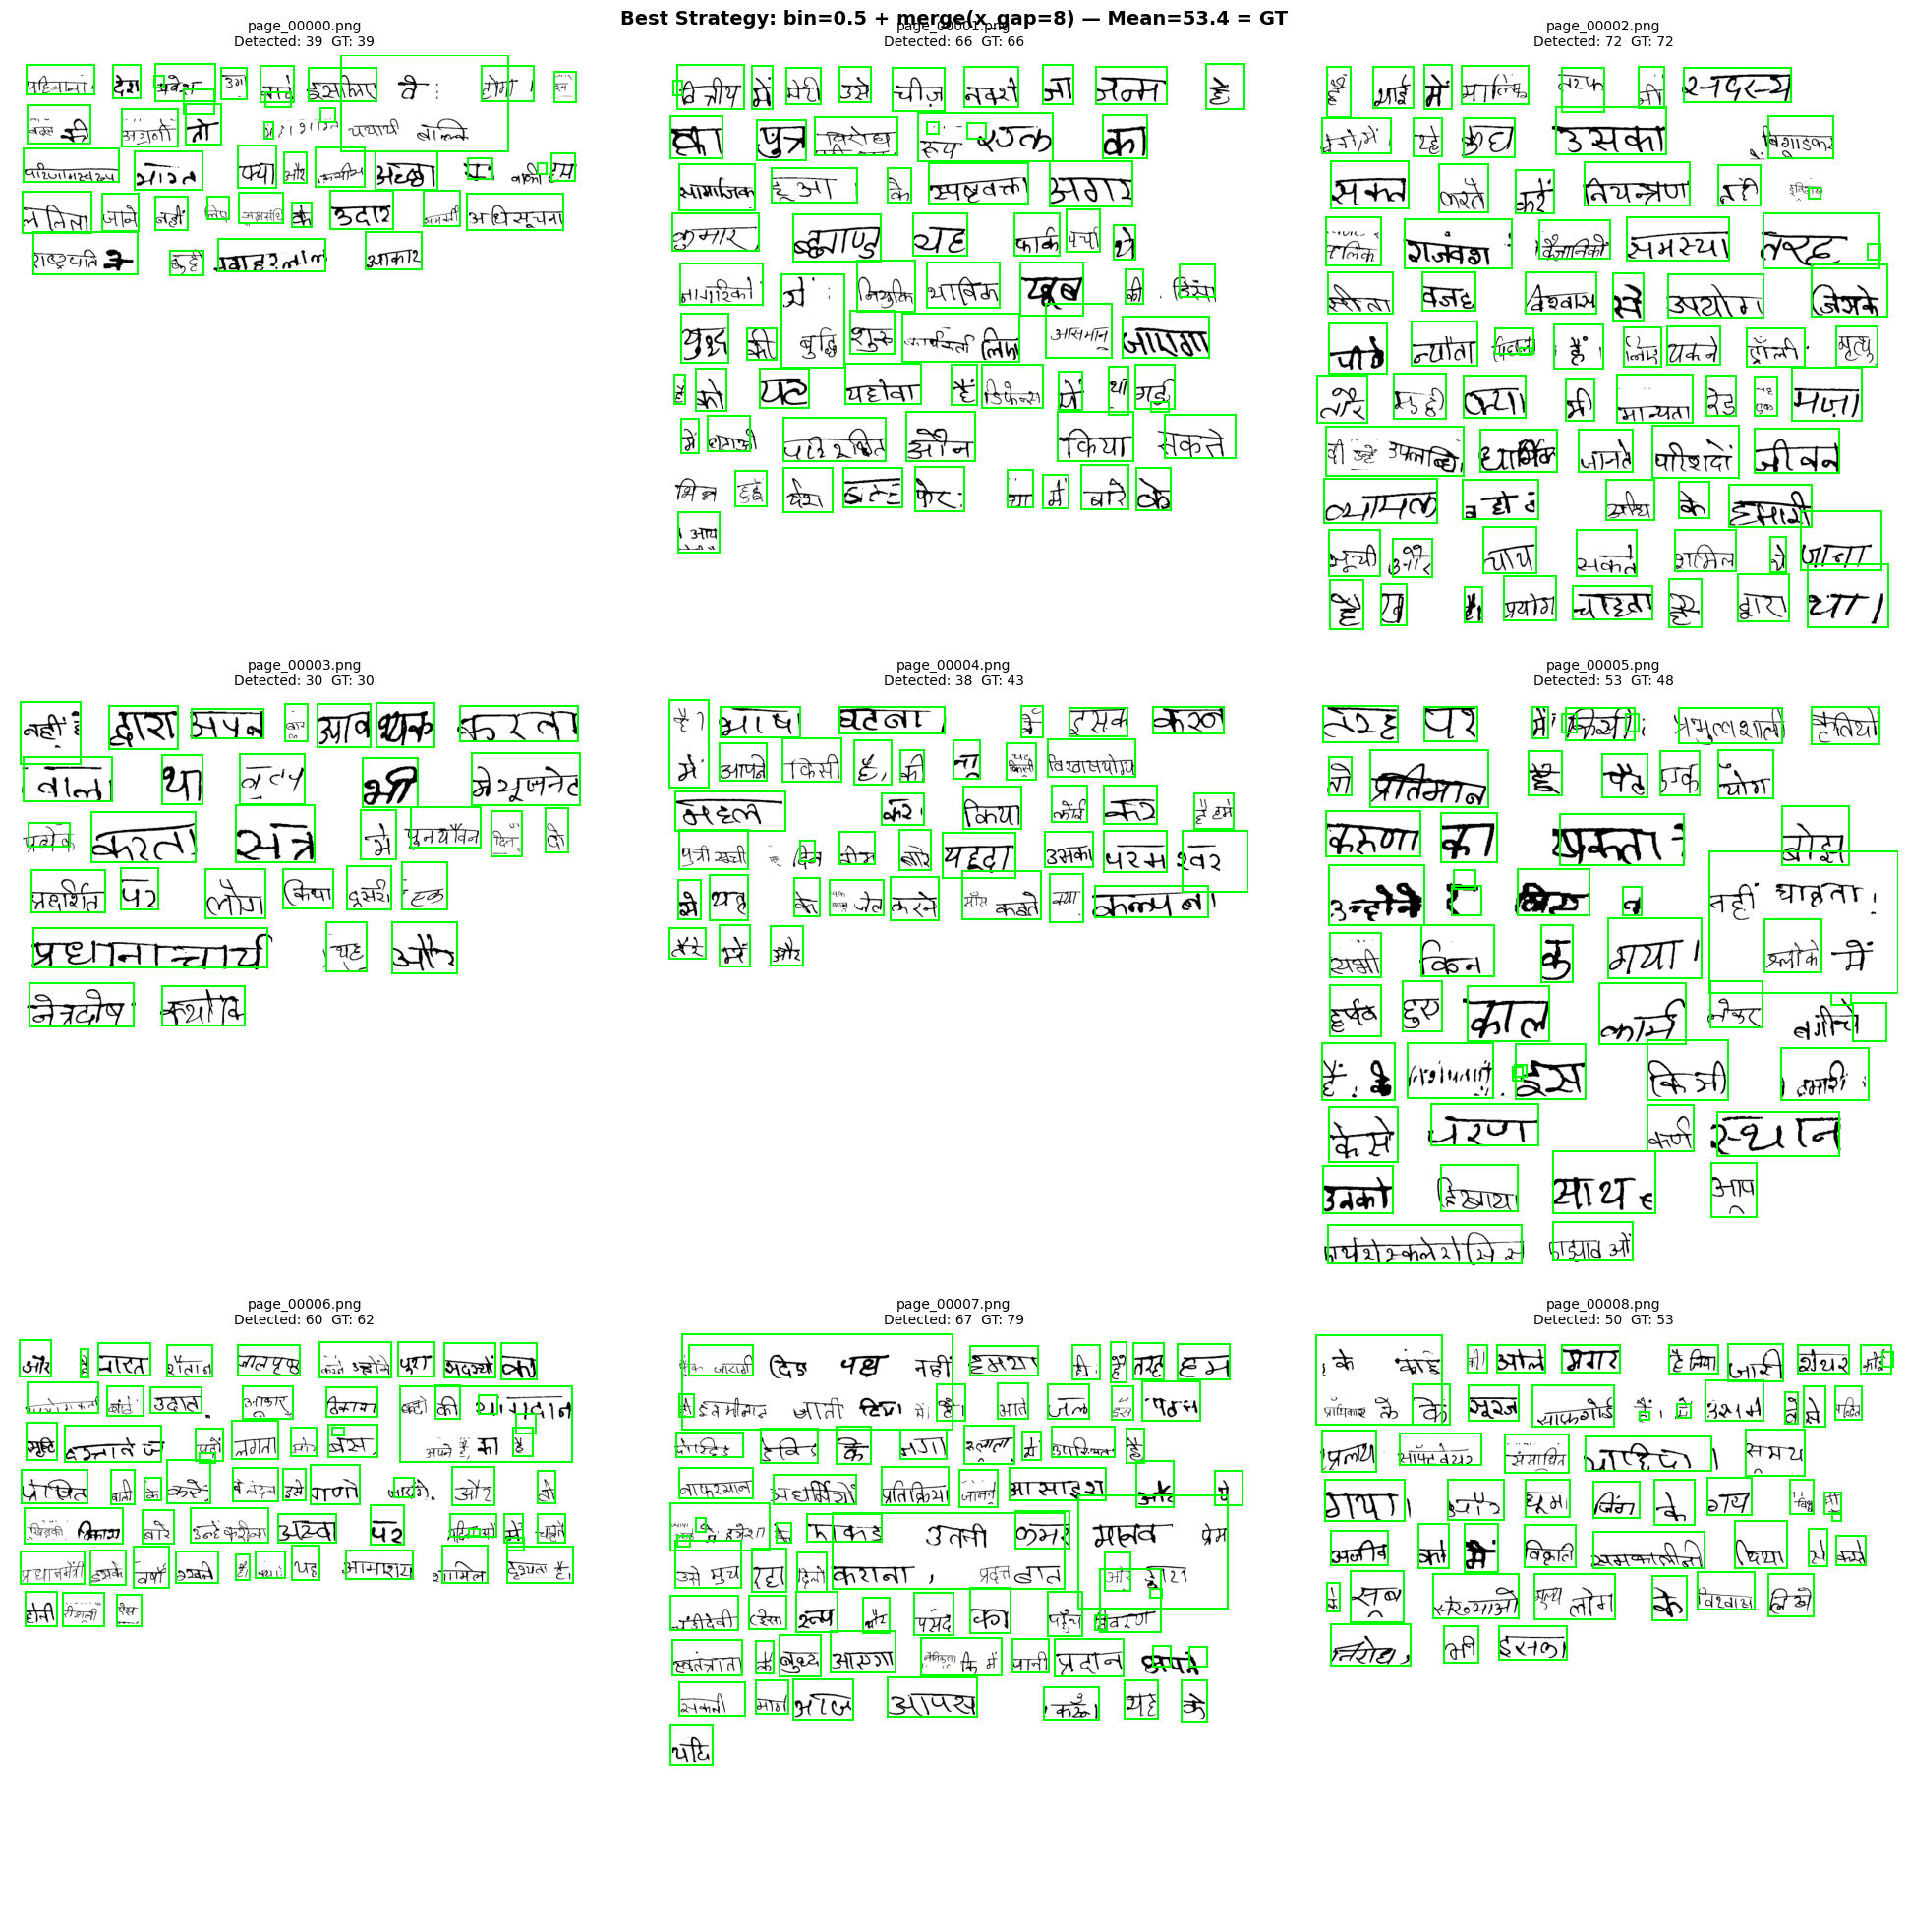

In [17]:
# ══════════════════════════════════════════════════════════════════════════════
# Best Strategy: bin=0.5 + x_gap=8 — Show 9 val pages
# ══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(3, 3, figsize=(20, 20))

for idx, img_path in enumerate(val_images[:9]):
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    fname = img_path.name
    gt_n = len(gt_labels.get(fname, {}).get("polygons", []))
    
    raw = predictor_05([img_rgb])[0]
    if isinstance(raw, dict):
        raw = raw.get('words', np.zeros((0, 5)))
    if not isinstance(raw, np.ndarray) or raw.ndim != 2:
        raw = np.zeros((0, 5))
    
    filtered = filter_tiny_boxes(raw, w, h, min_w=15, min_h=10)
    merged = merge_nearby_boxes(filtered, w, h, x_gap=8, y_overlap=0.4)
    
    ax = axes[idx // 3][idx % 3]
    ax.imshow(img_rgb)
    for b in merged:
        x1 = float(b[0]) * w
        y1 = float(b[1]) * h
        x2 = float(b[2]) * w
        y2 = float(b[3]) * h
        ax.add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1,
            linewidth=1.5, edgecolor='lime', facecolor='none'))
    ax.set_title(f"{fname}\nDetected: {len(merged)}  GT: {gt_n}", fontsize=10)
    ax.axis('off')

plt.suptitle("Best Strategy: bin=0.5 + merge(x_gap=8) — Mean=53.4 = GT",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "best_detection_9pages.png", dpi=120, bbox_inches='tight')
plt.show()

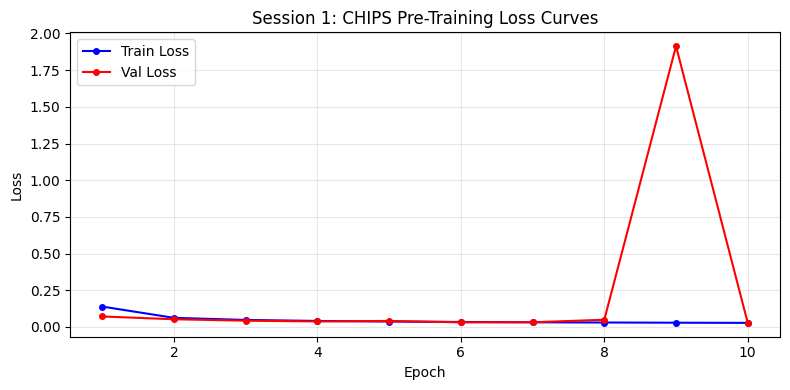

════════════════════════════════════════════════════════════
SESSION 1 COMPLETE
════════════════════════════════════════════════════════════
  Best val_loss: 0.0285
  Epochs run:    10
  Checkpoint:    /kaggle/working/phase4/dbnet_ckpt/dbnet_best.pt

NEXT STEP:
  Upload /kaggle/working/phase4/dbnet_ckpt/dbnet_best.pt as Kaggle dataset 'phase4-dbnet-ckpt'
  Then run session 2 (fine-tuning on manual annotations).


In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 5: Save Session 1 Artifacts
# ══════════════════════════════════════════════════════════════════════════════

# Plot training curves
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(train_losses)+1), train_losses, 'b-o', label='Train Loss', markersize=4)
ax.plot(range(1, len(val_losses)+1), val_losses, 'r-o', label='Val Loss', markersize=4)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Session 1: CHIPS Pre-Training Loss Curves')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "session1_loss_curves.png", dpi=120)
plt.show()

# Save session info
session1_info = {
    "best_val_loss": best_val_loss,
    "total_epochs": len(train_losses),
    "train_losses": train_losses,
    "val_losses": val_losses,
    "dbnet_ckpt": str(BEST_CKPT),
    "chips_train_dir": str(CHIPS_TRAIN),
    "chips_val_dir": str(CHIPS_VAL),
    "config": {
        "DET_IMG_SIZE": DET_IMG_SIZE,
        "DET_BS": DET_BS,
        "DET_LR": DET_LR,
        "DET_WD": DET_WD,
        "DET_EPOCHS": DET_EPOCHS,
        "DET_PATIENCE": DET_PATIENCE,
        "GRAD_CLIP": GRAD_CLIP,
    }
}
with open(OUTPUT_DIR / "session1_info.json", "w") as f:
    json.dump(session1_info, f, indent=2)

print("═" * 60)
print("SESSION 1 COMPLETE")
print("═" * 60)
print(f"  Best val_loss: {best_val_loss:.4f}")
print(f"  Epochs run:    {len(train_losses)}")
print(f"  Checkpoint:    {BEST_CKPT}")
print(f"")
print(f"NEXT STEP:")
print(f"  Upload {BEST_CKPT} as Kaggle dataset 'phase4-dbnet-ckpt'")
print(f"  Then run session 2 (fine-tuning on manual annotations).")